Imports + setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1995)

true_lambda = 10
true_mean = 1 / true_lambda

Draw parent distribution


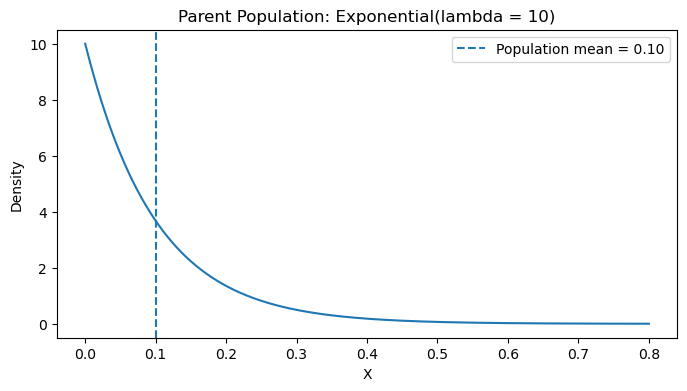

In [2]:
x = np.linspace(0, 0.8, 1000)
pdf = true_lambda * np.exp(-true_lambda * x)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.axvline(true_mean, linestyle="--", label=f"Population mean = {true_mean:.2f}")
plt.title("Parent Population: Exponential(lambda = 10)")
plt.xlabel("X")
plt.ylabel("Density")
plt.legend()
plt.show()

Freeze 3 samples of size 4

In [3]:
n = 4

samples = {
    "sample_1": np.random.exponential(scale=1/true_lambda, size=n),
    "sample_2": np.random.exponential(scale=1/true_lambda, size=n),
    "sample_3": np.random.exponential(scale=1/true_lambda, size=n),
}

pd.DataFrame(samples).T

,0,1,2,3
sample_1,0.042852,0.046555,0.058796,0.086643
sample_2,0.332582,0.324947,0.028366,0.119019
sample_3,0.052121,0.132577,0.019343,0.052955


Plot parent + 3 sample points

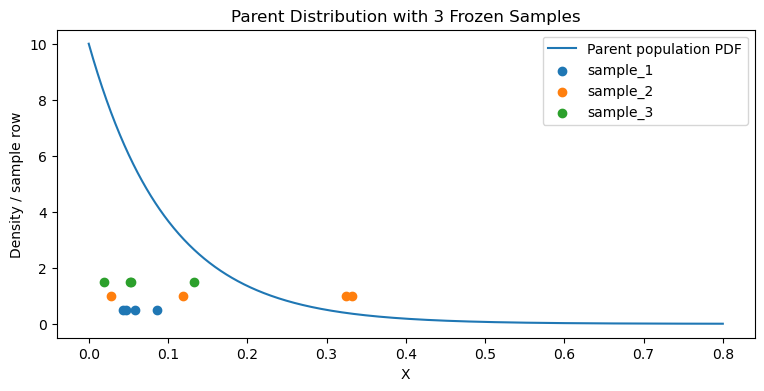

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(x, pdf, label="Parent population PDF")

y_positions = [0.5, 1.0, 1.5]

for i, (name, sample) in enumerate(samples.items()):
    plt.scatter(sample, [y_positions[i]] * len(sample), label=name)

plt.title("Parent Distribution with 3 Frozen Samples")
plt.xlabel("X")
plt.ylabel("Density / sample row")
plt.legend()
plt.show()

Define estimator functions for lambda

In [5]:
def lambda_mle(sample):
    """
    MLE estimator for exponential rate lambda.
    Biased upward for small n, but consistent.
    """
    return len(sample) / np.sum(sample)


def lambda_unbiased(sample):
    """
    Bias-corrected estimator for exponential rate lambda.
    Unbiased for n > 1.
    """
    n = len(sample)
    return (n - 1) / np.sum(sample)


def lambda_first3_unbiased(sample):
    """
    Uses only first 3 observations.
    Still unbiased if sample size >= 3, but less efficient because it throws away data.
    """
    first3 = sample[:3]
    return (len(first3) - 1) / np.sum(first3)


def lambda_bad_shifted(sample):
    """
    Bad estimator: MLE + 2.
    Biased and not consistent for lambda.
    """
    return lambda_mle(sample) + 2

Apply estimators to frozen samples

In [6]:
rows = []

for name, sample in samples.items():
    rows.append({
        "sample": name,
        "values": np.round(sample, 4),
        "true_lambda": true_lambda,
        "MLE": lambda_mle(sample),
        "Unbiased": lambda_unbiased(sample),
        "First3_Unbiased_But_Inefficient": lambda_first3_unbiased(sample),
        "Bad_Shifted": lambda_bad_shifted(sample),
    })

estimates_df = pd.DataFrame(rows)
estimates_df

,sample,values,true_lambda,MLE,Unbiased,First3_Unbiased_But_Inefficient,Bad_Shifted
0,sample_1,"[0.0429, 0.0466, 0.0588, 0.0866]",10,17.032425,12.774318,13.494986,19.032425
1,sample_2,"[0.3326, 0.3249, 0.0284, 0.119]",10,4.969470,3.727102,2.915896,6.969470
2,sample_3,"[0.0521, 0.1326, 0.0193, 0.053]",10,15.564505,11.673378,9.802003,17.564505


Simulate many samples, same n=4

In [7]:
num_simulations = 50_000
n = 4

estimator_outputs = {
    "MLE": [],
    "Unbiased": [],
    "First3_Unbiased_But_Inefficient": [],
    "Bad_Shifted": []
}

for _ in range(num_simulations):
    sample = np.random.exponential(scale=1/true_lambda, size=n)
    
    estimator_outputs["MLE"].append(lambda_mle(sample))
    estimator_outputs["Unbiased"].append(lambda_unbiased(sample))
    estimator_outputs["First3_Unbiased_But_Inefficient"].append(lambda_first3_unbiased(sample))
    estimator_outputs["Bad_Shifted"].append(lambda_bad_shifted(sample))

sim_df = pd.DataFrame(estimator_outputs)
sim_df.describe()

,MLE,Unbiased,First3_Unbiased_But_Inefficient,Bad_Shifted
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.388943,10.041707,10.032804,15.388943
std,9.278267,6.958700,9.787553,9.278267
min,2.073181,1.554886,1.049182,4.073181
25%,7.860364,5.895273,5.116852,9.860364
50%,10.938774,8.204080,7.521574,12.938774
75%,15.888684,11.916513,11.665453,17.888684
max,191.189807,143.392355,633.575353,193.189807


Compare bias and variance numerically

In [8]:
summary = pd.DataFrame({
    "average_estimate": sim_df.mean(),
    "bias": sim_df.mean() - true_lambda,
    "variance": sim_df.var(),
    "std_dev": sim_df.std()
})

summary

,average_estimate,bias,variance,std_dev
MLE,13.388943,3.388943,86.086245,9.278267
Unbiased,10.041707,0.041707,48.423513,6.958700
First3_Unbiased_But_Inefficient,10.032804,0.032804,95.796194,9.787553
Bad_Shifted,15.388943,5.388943,86.086245,9.278267


Plot estimator distributions

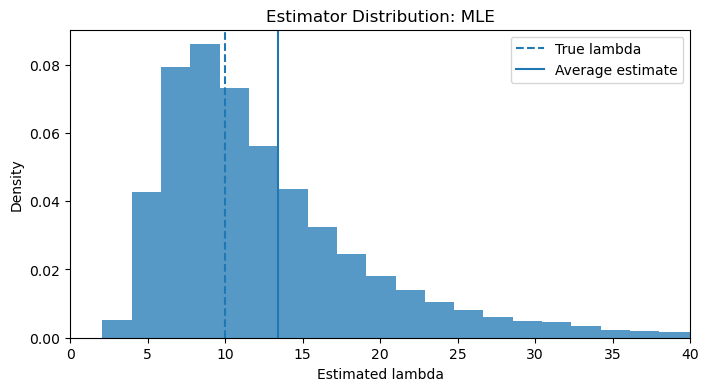

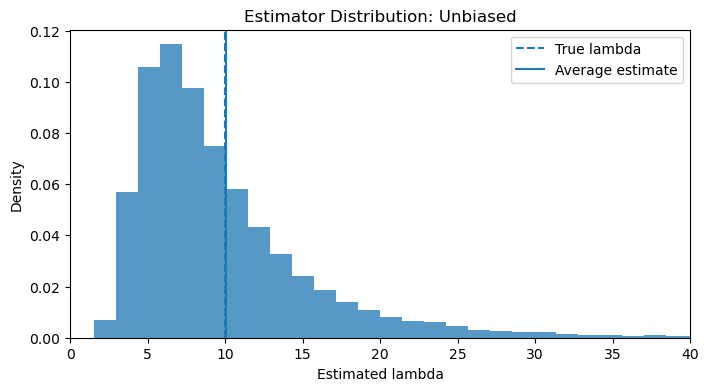

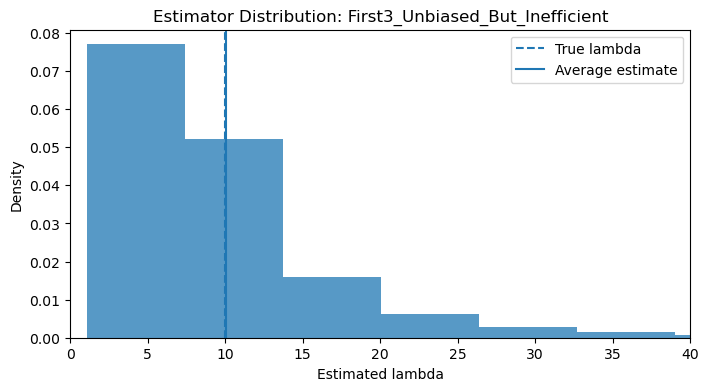

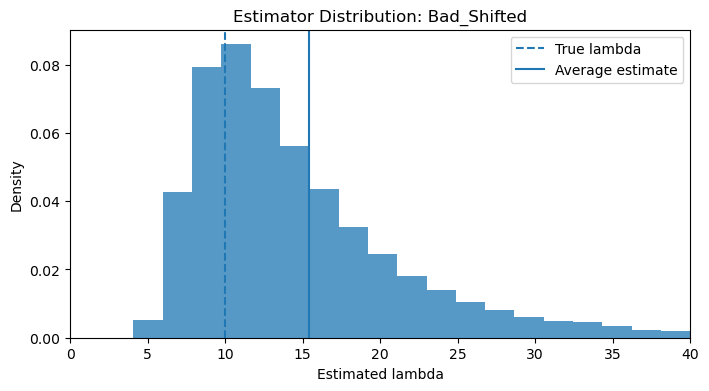

In [9]:
for col in sim_df.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(sim_df[col], bins=100, density=True, alpha=0.75)
    plt.axvline(true_lambda, linestyle="--", label="True lambda")
    plt.axvline(sim_df[col].mean(), linestyle="-", label="Average estimate")
    plt.title(f"Estimator Distribution: {col}")
    plt.xlabel("Estimated lambda")
    plt.ylabel("Density")
    plt.xlim(0, 40)
    plt.legend()
    plt.show()

Consistency simulation as n increases

In [10]:
sample_sizes = [4, 10, 30, 100, 300, 1000, 3000]
num_simulations = 10_000

consistency_rows = []

for n in sample_sizes:
    for estimator_name, estimator_func in {
        "MLE": lambda_mle,
        "Unbiased": lambda_unbiased,
        "Bad_Shifted": lambda_bad_shifted
    }.items():
        
        estimates = []
        
        for _ in range(num_simulations):
            sample = np.random.exponential(scale=1/true_lambda, size=n)
            estimates.append(estimator_func(sample))
        
        estimates = np.array(estimates)
        
        consistency_rows.append({
            "n": n,
            "estimator": estimator_name,
            "average_estimate": estimates.mean(),
            "average_absolute_error": np.mean(np.abs(estimates - true_lambda)),
            "variance": estimates.var()
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_df

,n,estimator,average_estimate,average_absolute_error,variance
0,4,MLE,13.293855,5.602764,83.649113
1,4,Unbiased,10.054685,4.536908,51.117058
2,4,Bad_Shifted,15.263104,6.193989,90.986117
3,10,MLE,11.131449,2.880850,15.566237
4,10,Unbiased,10.026501,2.639418,12.409784
5,10,Bad_Shifted,13.137314,3.565977,15.100055
6,30,MLE,10.364897,1.539658,3.941728
7,30,Unbiased,10.023166,1.472746,3.547478
8,30,Bad_Shifted,12.368034,2.474853,3.824392
9,100,MLE,10.100778,0.806434,1.033023


Plot consistency

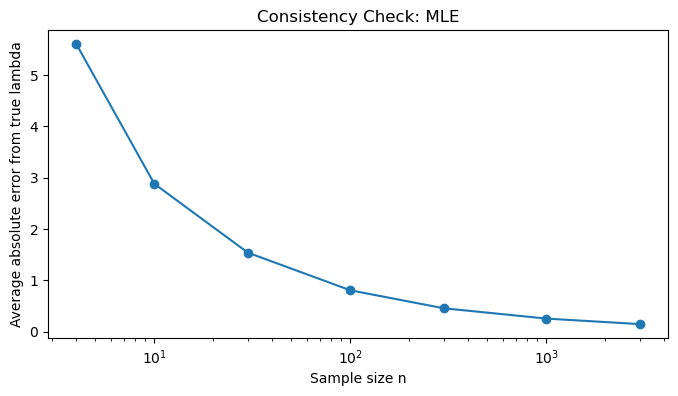

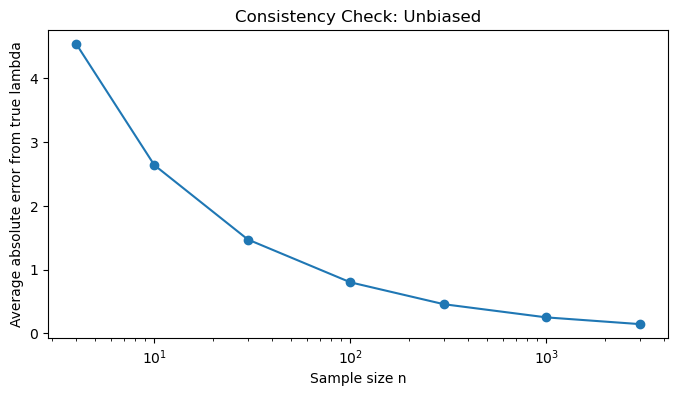

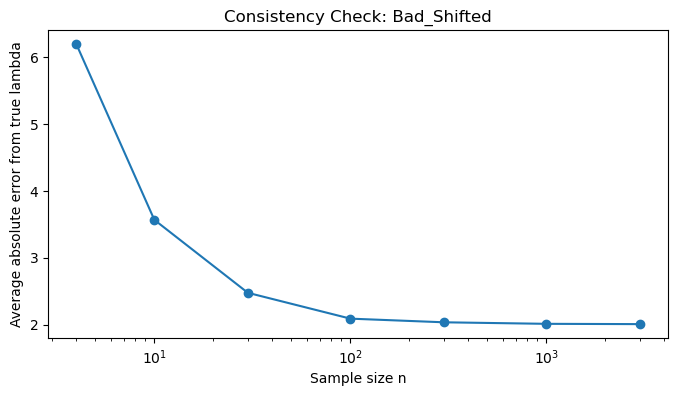

In [11]:
for estimator_name in consistency_df["estimator"].unique():
    temp = consistency_df[consistency_df["estimator"] == estimator_name]
    
    plt.figure(figsize=(8, 4))
    plt.plot(temp["n"], temp["average_absolute_error"], marker="o")
    plt.xscale("log")
    plt.title(f"Consistency Check: {estimator_name}")
    plt.xlabel("Sample size n")
    plt.ylabel("Average absolute error from true lambda")
    plt.show()